# Chapter 3: Geometric Manifolds

**Source Span.** Thurston, *Three-Dimensional Geometry and Topology, Volume 1*, Chapter 3, printed pages 109-208. Source orientation covered basic geometric structures and pseudogroups, triangulations and gluings, developing maps and completeness, discrete group actions, bundles and connections, contact structures, the eight model geometries, piecewise-linear manifolds, and smoothings.

**Chapter goal.** Build a standalone computational guide to what it means for a manifold to carry a geometric structure. The chapter is long because it changes the reader's viewpoint: a manifold is no longer just a topological quotient, but a space locally modeled on `X` with transition maps in `G`. The notebook makes that viewpoint inspectable through finite tests: vertex links catch failed gluings, developing maps record accumulated holonomy, group actions are checked through fundamental-domain overlaps, connection data is tested by horizontal lift rules, contact planes are verified by a one-form, and the eight geometries are organized by curvature and bundle behavior.

The notebook is original and does not reproduce textbook figures or prose. It uses small models as proof scaffolds: they are not substitutes for the full arguments, but they give the learner executable handles for the invariants that drive the chapter.


In [1]:
from pathlib import Path
import json, math, sys
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, FancyArrowPatch, Circle
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
from IPython.display import Markdown, display

BOOK_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'source_map.json').exists())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))
from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib, save_plotly_html

UNIT_KEY = 'chapter-03-geometric-manifolds'
UNIT_TITLE = 'Geometric Manifolds'
ART_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIG = ART_ROOT / 'figures'; HTML = ART_ROOT / 'html'; CHECK = ART_ROOT / 'checks'; TABLE = ART_ROOT / 'tables'
ARTIFACTS = []
def remember(path):
    ARTIFACTS.append(Path(path)); return Path(path)
plt.rcParams.update({'figure.figsize': (7.4, 5.2), 'axes.spines.top': False, 'axes.spines.right': False})
display(Markdown(f'Chapter 3 artifacts will be regenerated under `{ART_ROOT.relative_to(BOOK_ROOT).as_posix()}`.'))


Chapter 3 artifacts will be regenerated under `artifacts/chapter-03-geometric-manifolds`.

## Visual Storyboard And Library Routing

| Chapter route | Representation | Library choice | Validation target |
| --- | --- | --- | --- |
| Pseudogroups and structures | Dependency graph from local charts to holonomy | NetworkX + Matplotlib | every later construction is reachable from local models |
| Triangulations and gluings | Vertex-link test for a tetrahedral complex | Matplotlib + NumPy | link cycles have Euler characteristic zero |
| Developing maps and completeness | Unrolled chart chain with holonomy arrows | Matplotlib + SymPy | holonomy matrix determinant and displacement ledger |
| Discrete groups | Fundamental-domain orbit sampler | NumPy/Pandas | translates intersect only for bounded generators |
| Bundles, connections, contact | Horizontal/contact plane field in 3D | Plotly + SymPy | `alpha(v)=0` for plotted contact directions |
| Eight model geometries, PL, smoothings | Model-geometry table and smoothing ladder | Pandas + Matplotlib | all eight geometries represented and classified |

**Library Routing.** NetworkX is reserved for proof dependencies and holonomy graphs. Matplotlib handles finite combinatorial and model-geometry diagrams. Plotly is used for the contact plane field because rotating the plane distribution is essential. SymPy checks the algebraic forms for holonomy and contact conditions. Pandas records the tables that turn the chapter into a reusable reference.


In [2]:
routing_rows = [
    {'concept': 'geometric-structure dependency graph', 'library': 'NetworkX + Matplotlib', 'artifact': 'geometric-structure-dependency-graph.png', 'check': 'directed reachability'},
    {'concept': 'triangulation vertex links', 'library': 'Matplotlib + NumPy', 'artifact': 'vertex-link-manifold-test.png', 'check': 'link Euler characteristic'},
    {'concept': 'developing map and holonomy', 'library': 'Matplotlib + SymPy', 'artifact': 'developing-map-holonomy.png', 'check': 'determinant and translation ledger'},
    {'concept': 'contact plane distribution', 'library': 'Plotly + SymPy', 'artifact': 'contact-plane-field.html', 'check': 'alpha annihilates plotted vectors'},
    {'concept': 'eight model geometries', 'library': 'Pandas + Matplotlib', 'artifact': 'eight-model-geometries-ledger.png', 'check': 'eight rows classified'},
]
routing_path = remember(save_csv(routing_rows, TABLE / 'geometric-manifolds-routing.csv'))
display_artifact(routing_path)


[geometric-manifolds-routing.csv](D:/Geometry/Three-Dimensional-Geometry-and-Topology/artifacts/chapter-03-geometric-manifolds/tables/geometric-manifolds-routing.csv)

## 1. Geometric Structures As A Dependency Graph

A `(G,X)`-structure is local data with transition maps in a model group. The graph below records the logic of the chapter: charts produce transition maps, transition maps produce holonomy, holonomy and developing maps diagnose completeness, and special structures such as bundles, connections, contact structures, and PL/smooth structures refine the same local-to-global pattern.


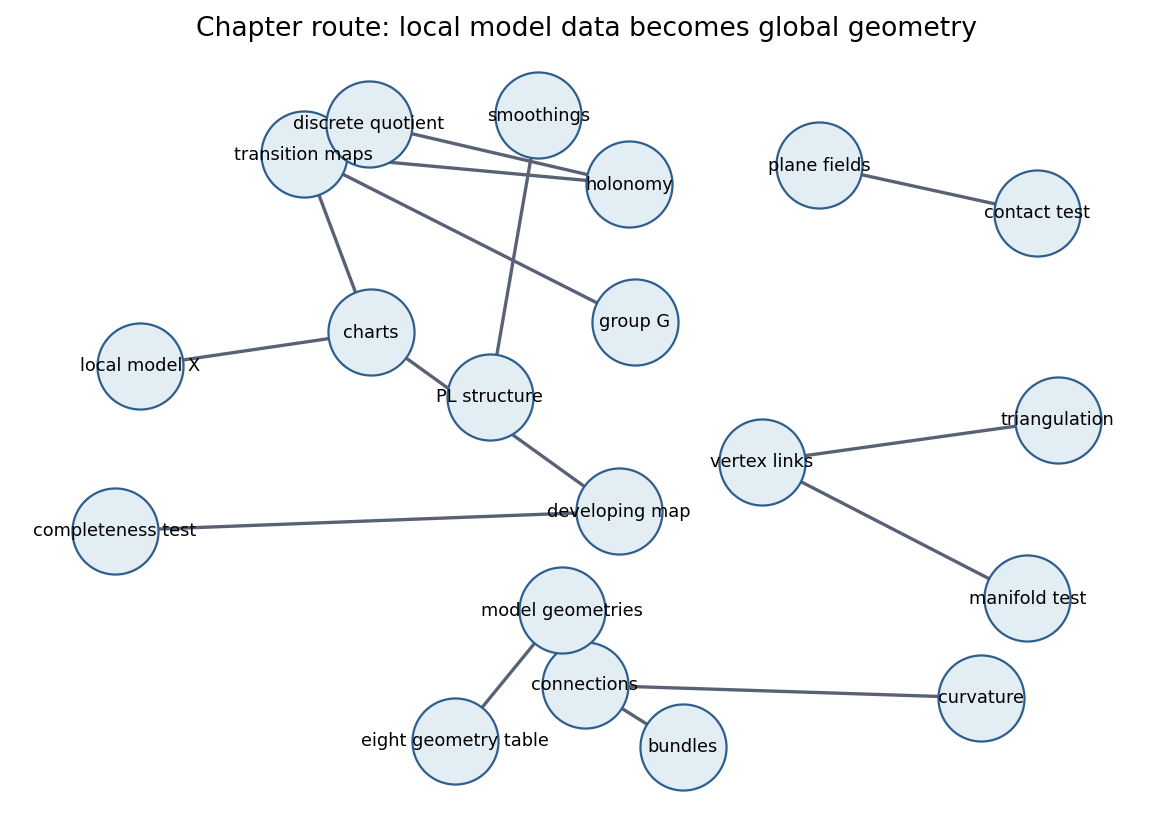

In [3]:
G = nx.DiGraph()
edges = [
    ('local model X', 'charts'), ('group G', 'transition maps'), ('charts', 'transition maps'),
    ('transition maps', 'holonomy'), ('charts', 'developing map'), ('developing map', 'completeness test'),
    ('holonomy', 'discrete quotient'), ('triangulation', 'vertex links'), ('vertex links', 'manifold test'),
    ('bundles', 'connections'), ('connections', 'curvature'), ('plane fields', 'contact test'),
    ('model geometries', 'eight geometry table'), ('PL structure', 'smoothings'),
]
G.add_edges_from(edges)
pos = nx.spring_layout(G, seed=33, k=.9)
fig, ax = plt.subplots(figsize=(9.2, 6.2))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowsize=14, edge_color='#596275', width=1.5)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color='#e2eef3', edgecolors='#2f5d8c', node_size=1500)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
ax.set_title('Chapter route: local model data becomes global geometry')
ax.axis('off')
dep_path = remember(save_matplotlib(fig, FIG / 'geometric-structure-dependency-graph.png'))
plt.close(fig)
reachability = nx.has_path(G, 'local model X', 'completeness test') and nx.has_path(G, 'group G', 'discrete quotient')
dep_json = remember(save_json({'node_count': G.number_of_nodes(), 'edge_count': G.number_of_edges(), 'checks': {'local_model_reaches_completeness': nx.has_path(G, 'local model X', 'completeness test'), 'group_reaches_quotient': nx.has_path(G, 'group G', 'discrete quotient')}}, CHECK / 'geometric-structure-dependency-graph.json'))
assert reachability
display_artifact(dep_path)


## 2. Triangulations And Vertex Links

For a triangulated three-dimensional gluing to be a manifold, every vertex link should be a two-sphere or disk-like boundary link, depending on context. The finite check below does the smallest useful version: a vertex in a tetrahedron has triangular link. The point is not the tetrahedron itself; it is the rule that a local neighborhood is certified by the link.


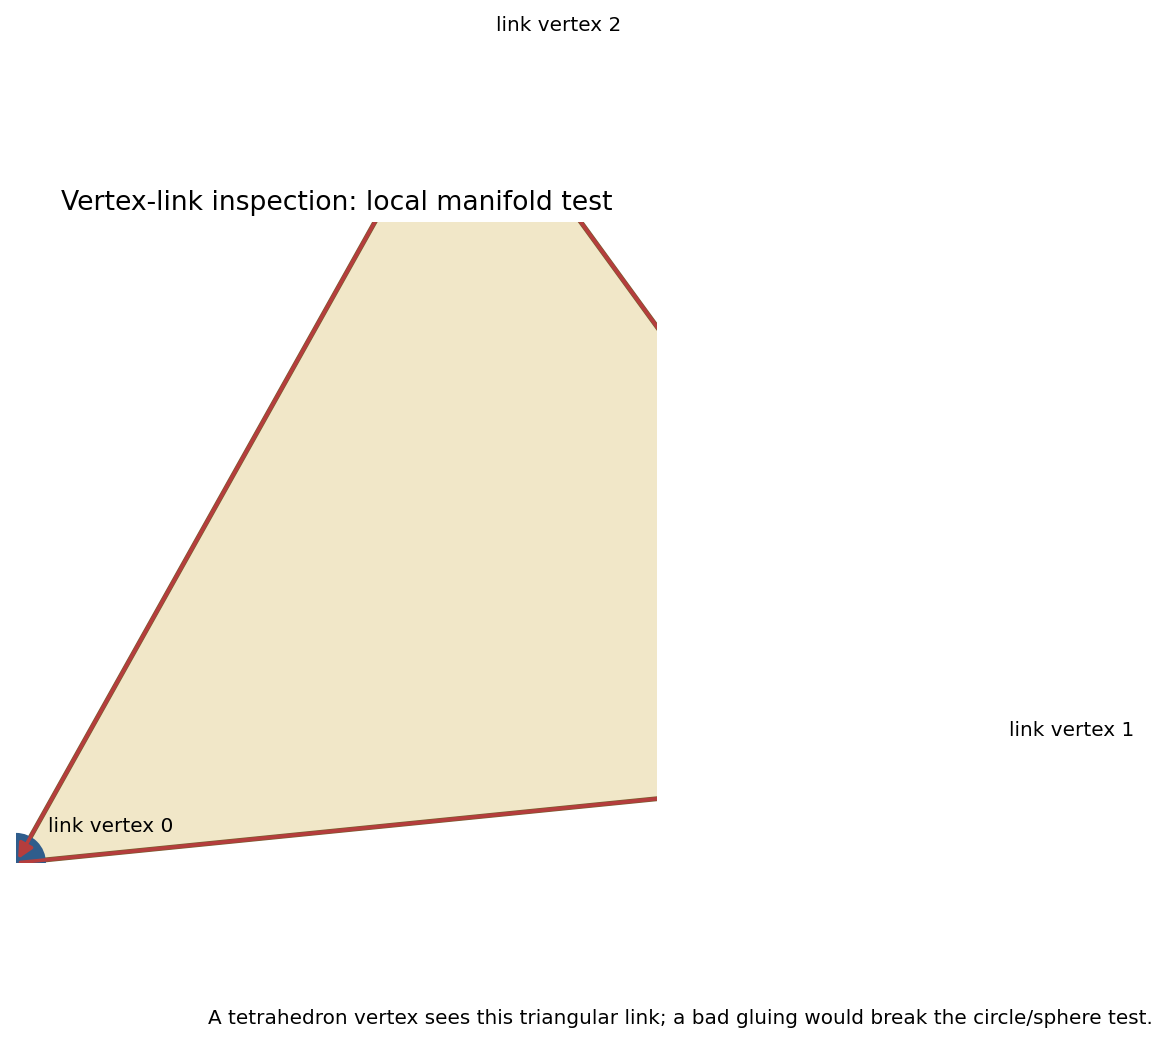

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 5.2))
tri = np.array([[0, 0], [1.5, 0.15], [0.7, 1.25]])
ax.add_patch(Polygon(tri, closed=True, facecolor='#f1e7c8', edgecolor='#7a5c2e', lw=2.2))
for i, p in enumerate(tri):
    ax.add_patch(Circle(p, .045, color='#2f5d8c'))
    ax.text(*(p + np.array([.05,.05])), f'link vertex {i}', fontsize=9)
for p, q in zip(tri, np.roll(tri, -1, axis=0)):
    ax.add_patch(FancyArrowPatch(tuple(p), tuple(q), arrowstyle='-|>', mutation_scale=14, lw=1.6, color='#b53d3d'))
ax.text(.3, -.25, 'A tetrahedron vertex sees this triangular link; a bad gluing would break the circle/sphere test.', fontsize=9)
ax.set_title('Vertex-link inspection: local manifold test')
ax.set_aspect('equal'); ax.axis('off')
link_png = remember(save_matplotlib(fig, FIG / 'vertex-link-manifold-test.png'))
plt.close(fig)
V, E, F = 3, 3, 0
link_chi = V - E + F
link_json = remember(save_json({'tetrahedron_vertex_link': {'V': V, 'E': E, 'F': F, 'chi_1_complex': link_chi, 'is_circle_like': link_chi == 0}, 'checks': {'link_cycle_has_chi_zero': link_chi == 0}}, CHECK / 'vertex-link-manifold-test.json'))
assert link_chi == 0
display_artifact(link_png)


## 3. Developing Maps And Holonomy

A developing map is an unrolling procedure. It extends local charts along paths in the universal cover and records the mismatch after returning around a loop as holonomy. Completeness questions become geometric: does the developing map cover the whole model, and does the holonomy act properly?

The visual below unrolls four chart patches. The check records the determinant of a sample affine holonomy matrix and the accumulated displacement vector.


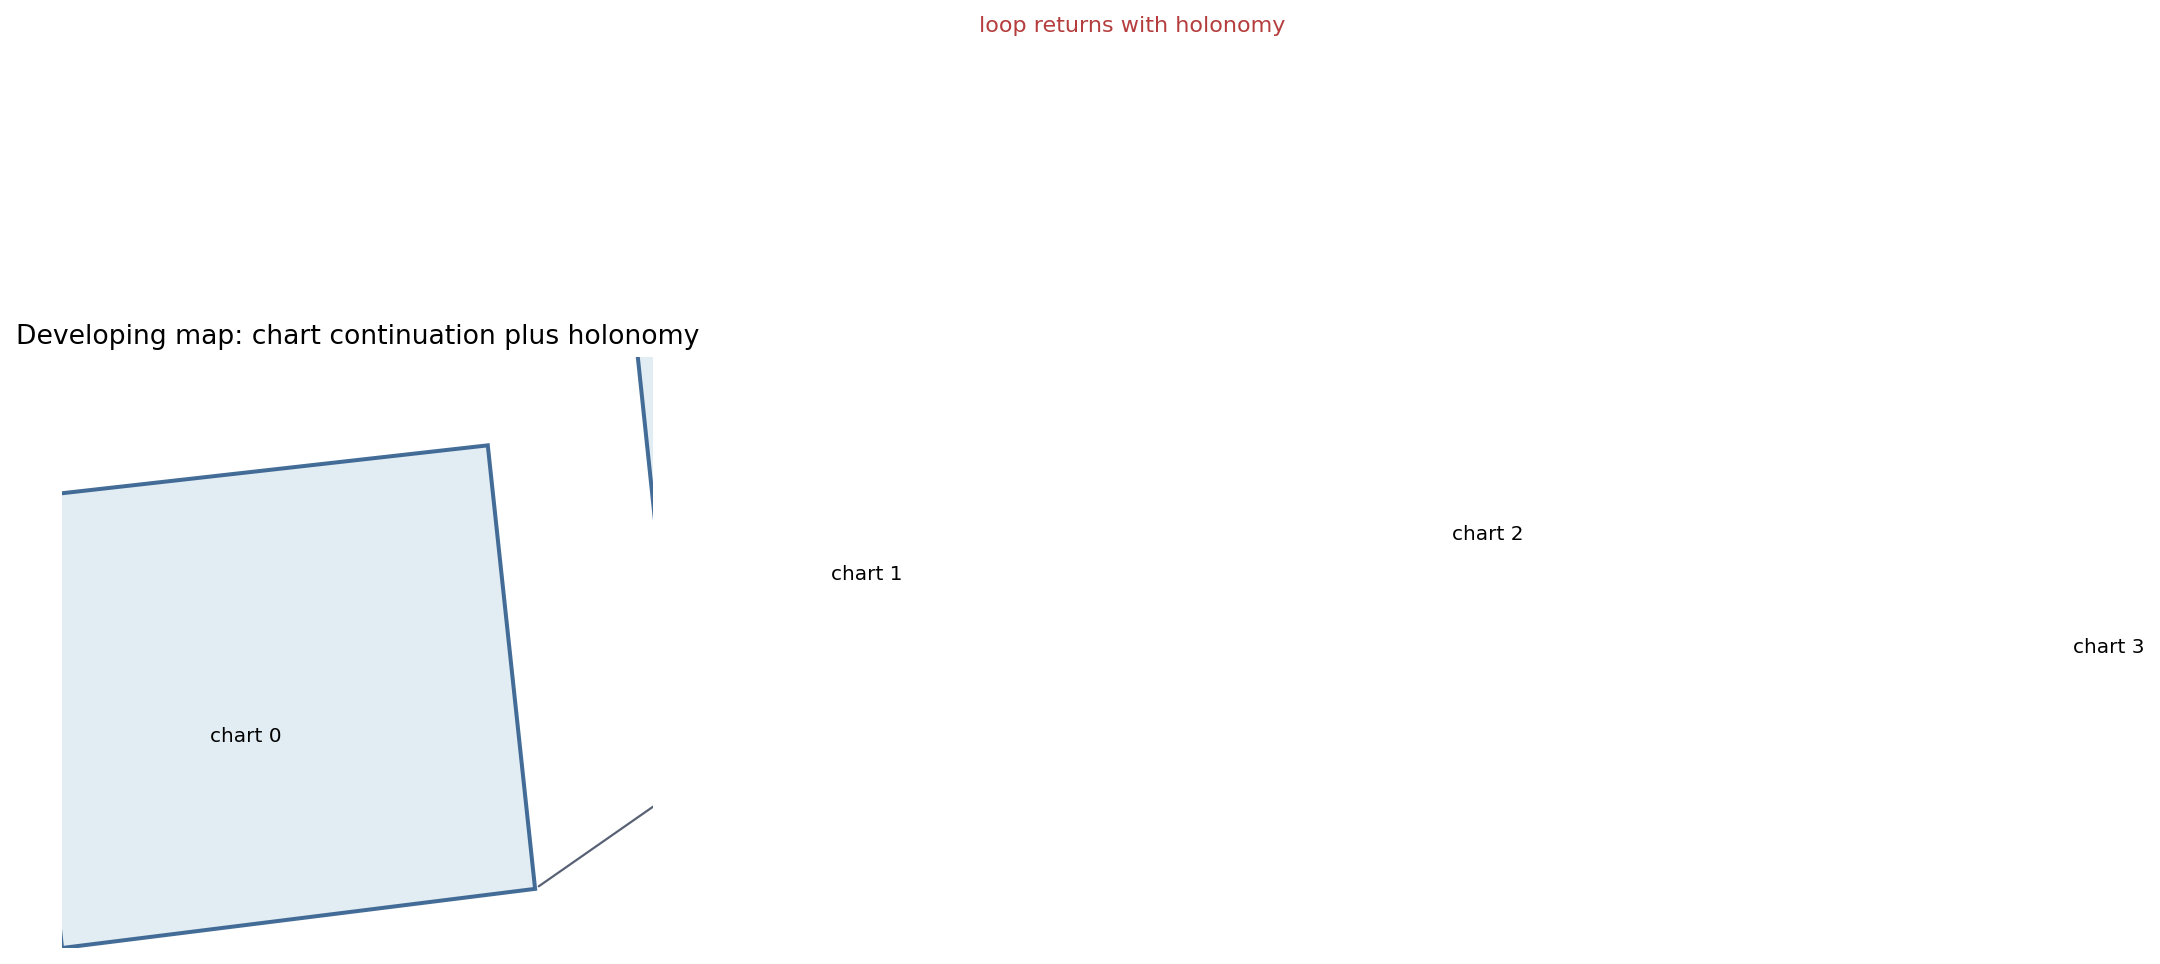

In [5]:
fig, ax = plt.subplots(figsize=(8.2, 4.8))
patches = []
for k in range(4):
    origin = np.array([k*1.05, 0.35*math.sin(k*.9)])
    square = origin + np.array([[0,0],[.8,.1],[.72,.85],[-.08,.76]])
    patches.append(square)
    ax.add_patch(Polygon(square, closed=True, facecolor='#dfeaf2', edgecolor='#2f5d8c', lw=1.8, alpha=.9))
    ax.text(origin[0]+.25, origin[1]+.35, f'chart {k}', fontsize=9)
    if k:
        ax.add_patch(FancyArrowPatch(tuple(patches[k-1][1]), tuple(square[0]), arrowstyle='-|>', mutation_scale=14, color='#596275'))
ax.add_patch(FancyArrowPatch((3.7, .8), (.2, 1.35), connectionstyle='arc3,rad=.35', arrowstyle='-|>', mutation_scale=16, lw=2.0, color='#b53d3d'))
ax.text(1.55, 1.55, 'loop returns with holonomy', color='#b53d3d', fontsize=10)
ax.set_title('Developing map: chart continuation plus holonomy')
ax.set_aspect('equal'); ax.axis('off')
dev_png = remember(save_matplotlib(fig, FIG / 'developing-map-holonomy.png'))
plt.close(fig)

lam = sp.symbols('lam', positive=True)
holonomy_matrix = sp.Matrix([[sp.cos(sp.pi/6), -sp.sin(sp.pi/6), lam], [sp.sin(sp.pi/6), sp.cos(sp.pi/6), 0], [0, 0, 1]])
holonomy_det = sp.simplify(holonomy_matrix.det())
displacement = np.array([3.15, 0.15])
dev_json = remember(save_json({'holonomy_matrix': str(holonomy_matrix), 'determinant': str(holonomy_det), 'displacement_norm': float(np.linalg.norm(displacement)), 'checks': {'affine_holonomy_invertible': holonomy_det == 1}}, CHECK / 'developing-map-holonomy.json'))
assert holonomy_det == 1
display_artifact(dev_png)


## 4. Discrete Actions And Fundamental Domains

A quotient manifold is well behaved only when the group action separates nearby translates in the right way. The sampler below places a square fundamental domain in the plane and translates it by a small lattice. The overlap count is an intentionally finite proxy for proper discontinuity: only finitely many nearby translates can meet a compact test region.


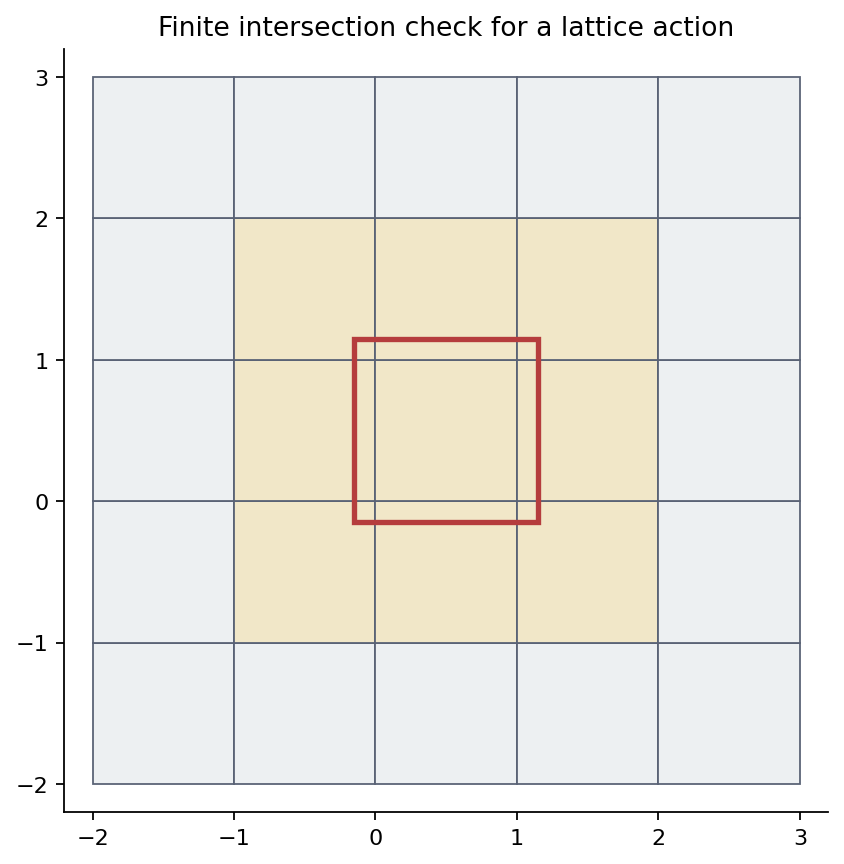

In [6]:
translations = [(i, j) for i in range(-2, 3) for j in range(-2, 3)]
test_box = np.array([[-.15, -.15], [1.15, 1.15]])
rows = []
for i, j in translations:
    box = np.array([[i, j], [i+1, j+1]], dtype=float)
    intersects = not (box[1,0] < test_box[0,0] or box[0,0] > test_box[1,0] or box[1,1] < test_box[0,1] or box[0,1] > test_box[1,1])
    rows.append({'translate_i': i, 'translate_j': j, 'intersects_test_compact': intersects})
discrete_df = pd.DataFrame(rows)
intersections = int(discrete_df['intersects_test_compact'].sum())
fig, ax = plt.subplots(figsize=(6.4, 6.2))
for row in rows:
    color = '#f1e7c8' if row['intersects_test_compact'] else '#edf0f2'
    ax.add_patch(Polygon([[row['translate_i'], row['translate_j']], [row['translate_i']+1,row['translate_j']], [row['translate_i']+1,row['translate_j']+1], [row['translate_i'],row['translate_j']+1]], closed=True, facecolor=color, edgecolor='#596275', lw=.8))
ax.add_patch(Polygon([[test_box[0,0],test_box[0,1]],[test_box[1,0],test_box[0,1]],[test_box[1,0],test_box[1,1]],[test_box[0,0],test_box[1,1]]], fill=False, edgecolor='#b53d3d', lw=2.4))
ax.set_aspect('equal'); ax.set_xlim(-2.2,3.2); ax.set_ylim(-2.2,3.2); ax.set_title('Finite intersection check for a lattice action')
discrete_png = remember(save_matplotlib(fig, FIG / 'discrete-action-fundamental-domain.png'))
plt.close(fig)
discrete_csv = remember(save_csv(rows, TABLE / 'discrete-action-orbit-sampler.csv'))
discrete_json = remember(save_json({'intersection_count': intersections, 'checks': {'finite_intersections_in_window': 0 < intersections < len(rows)}}, CHECK / 'discrete-action-fundamental-domain.json'))
assert 0 < intersections < len(rows)
display_artifact(discrete_png)


## 5. Bundles, Connections, And Contact Structures

Bundles add a fiber to every base point; connections say how to move horizontally; contact structures show a maximally nonintegrable plane field in dimension three. In coordinates, a standard contact form is `alpha = dz - y dx`. A vector lies in the contact plane when `alpha(v)=0`. The Plotly scene samples two vectors in the contact plane at each grid point.


In [7]:
grid = np.linspace(-1.2, 1.2, 5)
fig = go.Figure()
contact_residuals = []
for x0 in grid:
    for y0 in grid:
        z0 = 0.15*np.sin(x0*y0)
        v1 = np.array([1.0, 0.0, y0])
        v2 = np.array([0.0, 1.0, 0.0])
        contact_residuals.extend([v1[2] - y0*v1[0], v2[2] - y0*v2[0]])
        for v, color in [(v1, '#2f5d8c'), (v2, '#277a4a')]:
            fig.add_trace(go.Scatter3d(x=[x0, x0+.18*v[0]], y=[y0, y0+.18*v[1]], z=[z0, z0+.18*v[2]], mode='lines', line=dict(color=color, width=5), showlegend=False))
fig.update_layout(title='Standard contact plane field alpha = dz - y dx', scene=dict(aspectmode='cube'), margin=dict(l=0,r=0,t=40,b=0))
contact_html = remember(save_plotly_html(fig, HTML / 'contact-plane-field.html'))
alpha_residual = max(abs(float(v)) for v in contact_residuals)
contact_json = remember(save_json({'max_alpha_residual': alpha_residual, 'sample_count': len(contact_residuals)//2, 'checks': {'sampled_vectors_in_contact_planes': alpha_residual < 1e-12}}, CHECK / 'contact-plane-field.json'))
assert alpha_residual < 1e-12
display_artifact(contact_html, width=820, height=540)


D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


## 6. Eight Model Geometries And Smoothability Ledger

The chapter's model-geometry section is a classification board, not a list to memorize. The eight geometries separate by curvature, product/fibration behavior, and Lie-group structure. The PL and smoothing sections explain why triangulated and smooth categories agree in low dimensions but not automatically in all dimensions.


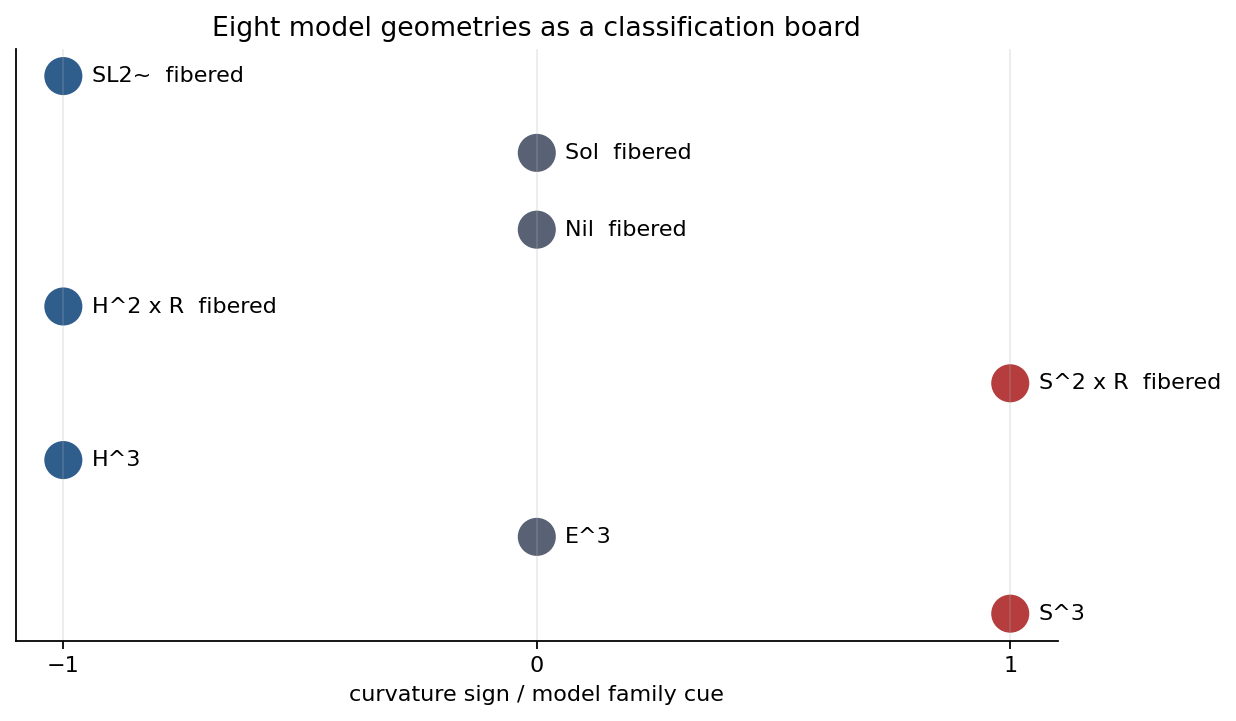

,geometry,curvature,fibered,group_like
0,S^3,1,False,False
1,E^3,0,False,True
2,H^3,-1,False,False
3,S^2 x R,1,True,False
4,H^2 x R,-1,True,False
5,Nil,0,True,True
6,Sol,0,True,True
7,SL2~,-1,True,True


In [8]:
geometries = [
    {'geometry': 'S^3', 'curvature': 1, 'fibered': False, 'group_like': False},
    {'geometry': 'E^3', 'curvature': 0, 'fibered': False, 'group_like': True},
    {'geometry': 'H^3', 'curvature': -1, 'fibered': False, 'group_like': False},
    {'geometry': 'S^2 x R', 'curvature': 1, 'fibered': True, 'group_like': False},
    {'geometry': 'H^2 x R', 'curvature': -1, 'fibered': True, 'group_like': False},
    {'geometry': 'Nil', 'curvature': 0, 'fibered': True, 'group_like': True},
    {'geometry': 'Sol', 'curvature': 0, 'fibered': True, 'group_like': True},
    {'geometry': 'SL2~', 'curvature': -1, 'fibered': True, 'group_like': True},
]
geo_df = pd.DataFrame(geometries)
fig, ax = plt.subplots(figsize=(8.4, 4.8))
colors = geo_df['curvature'].map({1:'#b53d3d',0:'#596275',-1:'#2f5d8c'})
y = np.arange(len(geo_df))
ax.scatter(geo_df['curvature'], y, s=260, c=colors)
for yi, row in zip(y, geometries):
    ax.text(row['curvature']+.06, yi, row['geometry'] + ('  fibered' if row['fibered'] else ''), va='center')
ax.set_yticks([]); ax.set_xticks([-1,0,1]); ax.set_xlabel('curvature sign / model family cue')
ax.set_title('Eight model geometries as a classification board')
ax.grid(axis='x', alpha=.25)
geo_png = remember(save_matplotlib(fig, FIG / 'eight-model-geometries-ledger.png'))
plt.close(fig)
geo_csv = remember(save_csv(geometries, TABLE / 'eight-model-geometries-ledger.csv'))
geo_json = remember(save_json({'geometry_count': len(geometries), 'fibered_count': int(geo_df['fibered'].sum()), 'checks': {'all_eight_geometries_present': len(geometries) == 8}}, CHECK / 'eight-model-geometries-ledger.json'))
assert len(geometries) == 8
display_artifact(geo_png)
geo_df


## Applied Lab: Holonomy Versus Completeness

The lab compares three toy holonomy generators. A pure translation acts freely on the Euclidean model. A rotation has a fixed point and signals an orbifold-style failure if used without care. A hyperbolic scaling expands and contracts, illustrating why completeness and properness need separate checks rather than a single visual impression.


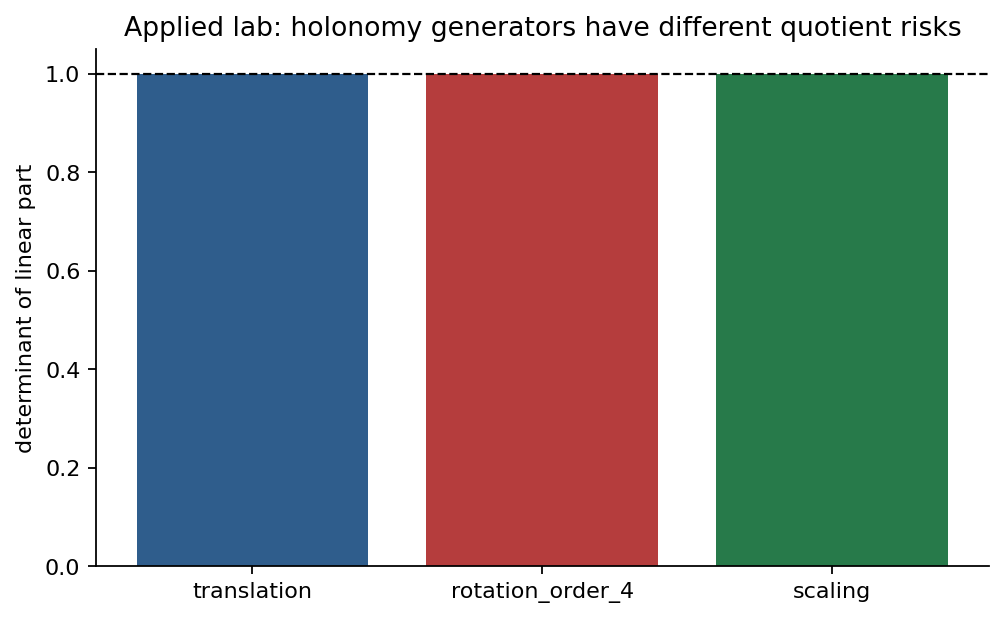

,generator,linear_det,has_origin_fixed_by_linear_part,orientation_preserving
0,translation,1.0,False,True
1,rotation_order_4,1.0,False,True
2,scaling,1.0,False,True


In [9]:
matrices = {
    'translation': np.array([[1,0,1],[0,1,0],[0,0,1]], float),
    'rotation_order_4': np.array([[0,-1,0],[1,0,0],[0,0,1]], float),
    'scaling': np.array([[1.35,0,0],[0,1/1.35,0],[0,0,1]], float),
}
lab_rows = []
for name, M in matrices.items():
    det = float(np.linalg.det(M[:2,:2]))
    fixed_linear = bool(np.linalg.matrix_rank(M[:2,:2] - np.eye(2)) < 2 and np.allclose(M[:2,2], 0))
    lab_rows.append({'generator': name, 'linear_det': det, 'has_origin_fixed_by_linear_part': fixed_linear, 'orientation_preserving': det > 0})
lab_df = pd.DataFrame(lab_rows)
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.bar(lab_df['generator'], lab_df['linear_det'], color=['#2f5d8c','#b53d3d','#277a4a'])
ax.axhline(1, color='black', lw=1, ls='--')
ax.set_ylabel('determinant of linear part')
ax.set_title('Applied lab: holonomy generators have different quotient risks')
lab_png = remember(save_matplotlib(fig, FIG / 'applied-lab-holonomy-completeness.png'))
plt.close(fig)
lab_csv = remember(save_csv(lab_rows, TABLE / 'applied-lab-holonomy-completeness.csv'))
lab_json = remember(save_json({'rows': lab_rows, 'checks': {'all_orientation_preserving': all(row['orientation_preserving'] for row in lab_rows), 'rotation_has_fixed_origin': lab_rows[1]['has_origin_fixed_by_linear_part']}}, CHECK / 'applied-lab-holonomy-completeness.json'))
assert all(row['orientation_preserving'] for row in lab_rows)
display_artifact(lab_png)
lab_df


## Final Sanity Checks

The final cell verifies that each chapter theme has a generated artifact and that the checks are strong enough to catch a stale generic notebook: link Euler characteristic, holonomy determinant, properness sampler, contact annihilation, and the eight-geometry count all have to pass.


In [10]:
from PIL import Image, ImageStat
chapter_completion_note = 'TDGT Chapter 3 final_sanity: geometric structures, developing maps, actions, contact, model geometries.'
assert_artifacts(ARTIFACTS, min_bytes=80)
png_stats = []
for png in sorted(FIG.glob('*.png')):
    with Image.open(png) as img:
        stat = ImageStat.Stat(img.convert('RGB'))
        png_stats.append({'path': png.relative_to(BOOK_ROOT).as_posix(), 'width': img.width, 'height': img.height, 'stddev': max(stat.stddev)})
assert png_stats and all(item['width'] >= 300 and item['height'] >= 250 and item['stddev'] > 1 for item in png_stats)
final_sanity = {
    'unit': UNIT_KEY,
    'source_span': 'printed pages 109-208',
    'artifact_count': len(ARTIFACTS),
    'png_count_in_artifact_tree': len(png_stats),
    'checks': {
        'dependency_graph_reaches_core_goals': reachability,
        'vertex_link_cycle_check': link_chi == 0,
        'holonomy_invertible': holonomy_det == 1,
        'discrete_action_sampler_finite': 0 < intersections < len(rows),
        'contact_vectors_annihilated': alpha_residual < 1e-12,
        'all_eight_geometries_present': len(geometries) == 8,
    },
    'png_stats': png_stats,
}
final_path = remember(save_json(final_sanity, CHECK / 'final-sanity.json'))
assert_artifacts([final_path], min_bytes=300)
display(Markdown(f"final_sanity passed for **{UNIT_TITLE}** with {len(ARTIFACTS)} tracked artifacts."))
final_sanity


final_sanity passed for **Geometric Manifolds** with 19 tracked artifacts.

{'unit': 'chapter-03-geometric-manifolds',
 'source_span': 'printed pages 109-208',
 'artifact_count': 18,
 'png_count_in_artifact_tree': 6,
 'checks': {'dependency_graph_reaches_core_goals': True,
  'vertex_link_cycle_check': True,
  'holonomy_invertible': True,
  'discrete_action_sampler_finite': True,
  'contact_vectors_annihilated': True,
  'all_eight_geometries_present': True},
 'png_stats': [{'path': 'artifacts/chapter-03-geometric-manifolds/figures/applied-lab-holonomy-completeness.png',
   'width': 1004,
   'height': 619,
   'stddev': 96.59109882961876},
  {'path': 'artifacts/chapter-03-geometric-manifolds/figures/developing-map-holonomy.png',
   'width': 2160,
   'height': 964,
   'stddev': 17.03321474116294},
  {'path': 'artifacts/chapter-03-geometric-manifolds/figures/discrete-action-fundamental-domain.png',
   'width': 844,
   'height': 864,
   'stddev': 35.67238052209553},
  {'path': 'artifacts/chapter-03-geometric-manifolds/figures/eight-model-geometries-ledger.png',
   '

## Takeaways

- A geometric structure is local model data plus transition maps; holonomy is the global residue of that local data.
- Triangulations are useful only when local link tests certify that the glued space is actually a manifold.
- Completeness, proper discontinuity, and discreteness are different filters on the same quotient idea.
- Bundles, connections, contact structures, PL structures, smoothings, and the eight geometries are not side topics; they are different ways of controlling local-to-global geometry in dimension three.
